In [85]:
# Run once only
#!pip install yfinance pandas numpy

# Income Objective Portfolio Construction (Bursa Malaysia)

Phase 1:
- Data collection
- Data cleaning
- Return computation
- Volatility classification (Stage 1 & Stage 2)

Benchmark: FTSE Bursa Malaysia KLCI

In [86]:
import yfinance as yf
import pandas as pd
import numpy as np
import os

# Fixed seed for reproducibility.
# The final stock selection is rules-based, but setting a seed supports reproducibility discipline.
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Phase 1
## 1. Candidate Pool Selection

A diversified candidate pool of 40 Bursa Malaysia stocks is used. The pool includes a mix of sectors such as banking, utilities, healthcare, technology, plantation, industrials, energy, retail, and telecommunications.

This avoids manually pre-selecting only stable or risky stocks. Instead, volatility classification is allowed to emerge from the computed return and volatility statistics.

In [87]:
stocks = [
    "1155.KL","1295.KL","1023.KL","5347.KL","5225.KL",
    "5819.KL","1961.KL","2445.KL","3816.KL","6012.KL",
    "4863.KL","6888.KL","1082.KL","5183.KL","6033.KL",
    "1818.KL","4707.KL","4197.KL","3182.KL","4715.KL",
    "1066.KL","2488.KL","4677.KL","6742.KL","1562.KL",
    "5296.KL","7113.KL","7106.KL","5168.KL","6947.KL",
    "0138.KL","5216.KL","7277.KL","7084.KL","7203.KL",
    "5285.KL","5681.KL","1619.KL","5211.KL","0166.KL"
]

# In saved files, it will be renamed to "fbmklci" to match the assignment requirement.
benchmark = "^KLSE"

print(f"Candidate pool size: {len(stocks)} stocks")

Candidate pool size: 40 stocks


## 2. Data Collection

3 years of daily adjusted closing prices are downloaded using Yahoo Finance.

In [88]:
print("Downloading 3 years of daily adjusted closing prices...")

raw_data = yf.download(
    stocks + [benchmark],
    period="3y",
    auto_adjust=True,
    progress=True
)

# Extract closing prices only.
prices = raw_data["Close"].copy()

# Sort dates chronologically to ensure correct time-series ordering.
prices = prices.sort_index()

# Separate stock prices and benchmark prices.
stock_prices = prices.drop(columns=[benchmark]).copy()
benchmark_prices = prices[benchmark].copy()

# Rename benchmark to match assignment requirement.
benchmark_prices.name = "fbmklci"

print("Download completed.")
print(f"Raw stock price shape: {stock_prices.shape}")
print(f"Benchmark observations: {benchmark_prices.shape[0]}")

[***                    7%                       ]  3 of 41 completed

[*********************100%***********************]  41 of 41 completed


Download completed.
Raw stock price shape: (741, 40)
Benchmark observations: 741


## 3. Data Cleaning and Alignment

Stocks with excessive missing values are removed using a 90% data availability threshold. This keeps the dataset reliable while avoiding unnecessary loss of diversification.

After cleaning, stock prices and FBMKLCI are aligned on the same trading dates.

In [89]:
minimum_required_observations = int(len(stock_prices) * 0.90)

stock_prices_clean = stock_prices.dropna(
    axis=1,
    thresh=minimum_required_observations
).copy()

# Combine cleaned stock prices with benchmark.
cleaned_prices = pd.concat([stock_prices_clean, benchmark_prices], axis=1)

# Drop rows where benchmark is missing.
cleaned_prices = cleaned_prices.dropna(subset=["fbmklci"])

# Forward filling is not used here because artificial prices may distort return and volatility estimates.
# Any remaining missing stock values will be handled during return calculation by dropping incomplete return rows.
print(f"Remaining stocks after cleaning: {len(stock_prices_clean.columns)}")
print(stock_prices_clean.columns.tolist())

print(f"\nCleaned price dataset shape including benchmark: {cleaned_prices.shape}")

Remaining stocks after cleaning: 40
['0138.KL', '0166.KL', '1023.KL', '1066.KL', '1082.KL', '1155.KL', '1295.KL', '1562.KL', '1619.KL', '1818.KL', '1961.KL', '2445.KL', '2488.KL', '3182.KL', '3816.KL', '4197.KL', '4677.KL', '4707.KL', '4715.KL', '4863.KL', '5168.KL', '5183.KL', '5211.KL', '5216.KL', '5225.KL', '5285.KL', '5296.KL', '5347.KL', '5681.KL', '5819.KL', '6012.KL', '6033.KL', '6742.KL', '6888.KL', '6947.KL', '7084.KL', '7106.KL', '7113.KL', '7203.KL', '7277.KL']

Cleaned price dataset shape including benchmark: (739, 41)


## 4. Log Return Calculation

Log returns are computed instead of simple percentage returns because the marking rubric expects log returns.

rₜ = ln(Pₜ / Pₜ₋₁)

Where:
- rₜ = daily log return at time t
- Pₜ = closing price at time t
- Pₜ₋₁ = closing price on the previous trading day
- ln = natural logarithm

Log returns are suitable for statistical analysis because they are time-additive and commonly used in financial modelling.

In [90]:
# Separate cleaned stock prices and benchmark again after alignment.
stock_prices_clean = cleaned_prices.drop(columns=["fbmklci"])
benchmark_prices_clean = cleaned_prices["fbmklci"]

# Compute daily log returns.
returns = np.log(stock_prices_clean / stock_prices_clean.shift(1))
benchmark_returns = np.log(benchmark_prices_clean / benchmark_prices_clean.shift(1))

# Remove rows with missing values after log return calculation.
# This ensures all selected assets and the benchmark are aligned on identical dates.
returns = returns.dropna(how="any")
benchmark_returns = benchmark_returns.dropna()

# Align stocks and benchmark on common dates.
common_dates = returns.index.intersection(benchmark_returns.index)
returns = returns.loc[common_dates]
benchmark_returns = benchmark_returns.loc[common_dates]

# Combined return dataset for traceability.
returns_with_benchmark = pd.concat([returns, benchmark_returns.rename("fbmklci")], axis=1)

print(f"Stock log return dataset shape: {returns.shape}")
print(f"Benchmark log return observations: {benchmark_returns.shape[0]}")
print(f"Date range: {returns.index.min().date()} to {returns.index.max().date()}")

Stock log return dataset shape: (738, 40)
Benchmark log return observations: 738
Date range: 2023-05-16 to 2026-05-15


## 5. Daily Statistics

For each stock, the following statistics are computed:

- Mean Return: average daily log return
- Volatility: standard deviation of daily log returns
- Annual Return: daily mean return × 252
- Annual Risk: daily volatility × √252

These statistics support Stage 1 and Stage 2 volatility classification.

In [91]:
mean_returns = returns.mean()
volatility = returns.std()

stats_full = pd.DataFrame({
    "Mean Return": mean_returns,
    "Volatility": volatility,
    "Annual Return": mean_returns * 252,
    "Annual Risk": volatility * np.sqrt(252)
})

# Remove zero-volatility stocks to avoid division errors.
stats_full = stats_full[stats_full["Volatility"] > 0].copy()

# Supporting efficiency metric.
# This is not the main Stage 1 selection rule because the income objective prioritises stability.
stats_full["Return/Risk Ratio"] = stats_full["Mean Return"] / stats_full["Volatility"]

display(stats_full.head())

,Mean Return,Volatility,Annual Return,Annual Risk,Return/Risk Ratio
0138.KL,0.000188,0.024897,0.047463,0.395227,0.007565
0166.KL,-0.000047,0.027434,-0.011813,0.435496,-0.001709
1023.KL,0.000883,0.012708,0.222391,0.201728,0.069447
1066.KL,0.000826,0.008841,0.208046,0.140345,0.093382
1082.KL,0.000214,0.009926,0.053896,0.157568,0.021547


## 6. Stage 1: Low-Volatility Stock Selection

The assignment states that Stage 1 should contain 10 low-volatility stocks where:

(daily r̄p > daily σp) 

If fewer than 10 stocks satisfy the rule, a stabiliser is applied:
- keep only stocks with positive mean returns, and
- select the 10 stocks with the lowest volatility.

This stabiliser is consistent with the income objective because income portfolios prioritise positive return and stable risk.

In [92]:
# Income objective: Stage 1 should avoid negative-return assets.
stats_positive = stats_full[stats_full["Mean Return"] > 0].copy()

print(f"Stocks with positive mean returns: {len(stats_positive)}")
print(f"Stocks excluded due to negative mean returns: {len(stats_full) - len(stats_positive)}")

# Step 1: Try the strict assignment condition.
low_vol_condition = stats_positive[
    stats_positive["Mean Return"] > stats_positive["Volatility"]
].copy()

print(f"Stocks satisfying strict Stage 1 rule (Mean Return > Volatility): {len(low_vol_condition)}")

# Step 2: Apply selection logic.
if len(low_vol_condition) >= 10:
    low_vol = low_vol_condition.sort_values(
        by="Volatility",
        ascending=True
    ).head(10).copy()
    
    low_vol_method = "Strict assignment rule: Mean Return > Volatility"

else:
    print("Fewer than 10 stocks met the strict Stage 1 rule.")
    print("Applying stabiliser: positive-return stocks with lowest volatility.")
    
    low_vol = stats_positive.sort_values(
        by="Volatility",
        ascending=True
    ).head(10).copy()
    
    low_vol_method = "Stabiliser: positive-return stocks with lowest volatility"

low_vol["Selection Method"] = low_vol_method

print("\nStage 1 Low-Volatility Stocks:")
display(low_vol[["Mean Return", "Volatility", "Annual Return", "Annual Risk", "Return/Risk Ratio"]])

Stocks with positive mean returns: 24
Stocks excluded due to negative mean returns: 16
Stocks satisfying strict Stage 1 rule (Mean Return > Volatility): 0
Fewer than 10 stocks met the strict Stage 1 rule.
Applying stabiliser: positive-return stocks with lowest volatility.

Stage 1 Low-Volatility Stocks:


,Mean Return,Volatility,Annual Return,Annual Risk,Return/Risk Ratio
1155.KL,0.000577,0.007774,0.145356,0.123414,0.074194
1066.KL,0.000826,0.008841,0.208046,0.140345,0.093382
5819.KL,0.000289,0.009315,0.072749,0.147864,0.030993
6033.KL,0.000274,0.009541,0.068953,0.151465,0.028677
5225.KL,0.000656,0.009658,0.165269,0.153320,0.067903
1082.KL,0.000214,0.009926,0.053896,0.157568,0.021547
1818.KL,0.000635,0.010283,0.160046,0.163244,0.061760
1295.KL,0.000488,0.010373,0.123058,0.164672,0.047075
5347.KL,0.000733,0.010735,0.184718,0.170420,0.068279
3816.KL,0.000363,0.010773,0.091381,0.171016,0.033661


## 7. Stage 2: High-Volatility Stock Selection

The assignment states that Stage 2 should add 5 high-volatility stocks where:

(daily σp > 3.0  of daily r̄p ) 

The full stock universe is used for this rule because Stage 2 is designed to test the effect of adding riskier stocks, including stocks with weak or negative recent performance.

In [93]:
high_vol_candidates = stats_full[
    stats_full["Volatility"] > 3 * stats_full["Mean Return"]
].copy()

print(f"Stocks satisfying Stage 2 high-volatility rule: {len(high_vol_candidates)}")

# If enough stocks satisfy the condition, choose the five with highest volatility.
# This ensures the Stage 2 addition truly represents a high-volatility regime.
if len(high_vol_candidates) >= 5:
    high_vol = high_vol_candidates.sort_values(
        by="Volatility",
        ascending=False
    ).head(5).copy()
    
    high_vol_method = "Assignment rule: Volatility > 3 × Mean Return"

else:
    print("⚠️ Fewer than 5 stocks met the high-volatility rule.")
    print("Applying stabiliser: selecting highest-volatility stocks from full universe.")
    
    high_vol = stats_full.sort_values(
        by="Volatility",
        ascending=False
    ).head(5).copy()
    
    high_vol_method = "Stabiliser: highest-volatility stocks"

high_vol["Meets High-Vol Rule"] = high_vol["Volatility"] > 3 * high_vol["Mean Return"]
high_vol["Selection Method"] = high_vol_method

print("\nStage 2 High-Volatility Additions:")
display(high_vol[["Mean Return", "Volatility", "Annual Return", "Annual Risk", "Return/Risk Ratio", "Meets High-Vol Rule"]])

negative_high_vol = high_vol[high_vol["Mean Return"] < 0]

if len(negative_high_vol) > 0:
    print("\nImportant note: Some Stage 2 high-volatility stocks have negative mean returns:")
    print(negative_high_vol.index.tolist())

Stocks satisfying Stage 2 high-volatility rule: 40

Stage 2 High-Volatility Additions:


,Mean Return,Volatility,Annual Return,Annual Risk,Return/Risk Ratio,Meets High-Vol Rule
5168.KL,-0.000706,0.032474,-0.177817,0.515514,-0.021729,True
5216.KL,-0.000388,0.030716,-0.097891,0.487604,-0.012647,True
7113.KL,-0.000392,0.030123,-0.098781,0.478185,-0.013013,True
4677.KL,0.001680,0.029546,0.423448,0.469031,0.056872,True
7106.KL,-0.001071,0.027472,-0.269787,0.436104,-0.038970,True



Important note: Some Stage 2 high-volatility stocks have negative mean returns:
['5168.KL', '5216.KL', '7113.KL', '7106.KL']


## 8. Final Selected Universes

- Stage 1 contains 10 low-volatility stocks.

- Stage 2 contains the Stage 1 stocks plus 5 high-volatility additions.

These two universes will be used in the next phase for annual return, annual risk, beta, Sharpe ratio, and portfolio optimisation.

In [94]:
stage1_stocks = list(low_vol.index)
stage2_additions = list(high_vol.index)
stage2_stocks = stage1_stocks + stage2_additions

selected_stocks = stage2_stocks

print("Stage 1 Low-Volatility Universe:")
print(stage1_stocks)

print("\nStage 2 High-Volatility Additions:")
print(stage2_additions)

print("\nStage 2 Full Universe:")
print(stage2_stocks)

print(f"\nStage 1 size: {len(stage1_stocks)}")
print(f"Stage 2 size: {len(stage2_stocks)}")

Stage 1 Low-Volatility Universe:
['1155.KL', '1066.KL', '5819.KL', '6033.KL', '5225.KL', '1082.KL', '1818.KL', '1295.KL', '5347.KL', '3816.KL']

Stage 2 High-Volatility Additions:
['5168.KL', '5216.KL', '7113.KL', '4677.KL', '7106.KL']

Stage 2 Full Universe:
['1155.KL', '1066.KL', '5819.KL', '6033.KL', '5225.KL', '1082.KL', '1818.KL', '1295.KL', '5347.KL', '3816.KL', '5168.KL', '5216.KL', '7113.KL', '4677.KL', '7106.KL']

Stage 1 size: 10
Stage 2 size: 15


## 9. Export Phase 1 Outputs

The following files are saved for reproducibility and for use in later phases:

- Candidate pool
- Cleaned price dataset
- Log return dataset
- Benchmark log returns
- Stock statistics
- Stage 1 selected stocks
- Stage 2 selected stocks
- Stage 1 and Stage 2 return datasets

In [95]:
OVERWRITE_OUTPUT = True

if OVERWRITE_OUTPUT:
    os.makedirs("output", exist_ok=True)

    # Candidate pool
    pd.Series(stocks, name="Candidate Pool").to_csv(
        "output/candidate_pool.csv",
        index=False
    )

    # Cleaned daily closing prices including benchmark labelled as fbmklci
    cleaned_prices.to_csv("output/cleaned_prices_with_fbmklci.csv")

    # Log returns
    returns.to_csv("output/log_returns.csv")
    benchmark_returns.rename("fbmklci").to_csv("output/fbmklci_log_returns.csv")
    returns_with_benchmark.to_csv("output/log_returns_with_fbmklci.csv")

    # Statistics and filtering outputs
    stats_full.to_csv("output/stock_statistics_full.csv")
    low_vol.to_csv("output/stage1_low_vol_stocks.csv")
    high_vol.to_csv("output/stage2_high_vol_additions.csv")

    # Selected stock lists
    pd.Series(stage1_stocks, name="Stage 1 Stocks").to_csv(
        "output/stage1_stocks.csv",
        index=False
    )

    pd.Series(stage2_additions, name="Stage 2 Additions").to_csv(
        "output/stage2_additions.csv",
        index=False
    )

    pd.Series(stage2_stocks, name="Stage 2 Full Universe").to_csv(
        "output/stage2_stocks.csv",
        index=False
    )

    # Return datasets for next phase
    returns_stage1 = returns[stage1_stocks].copy()
    returns_stage2 = returns[stage2_stocks].copy()

    returns_stage1.to_csv("output/log_returns_stage1.csv")
    returns_stage2.to_csv("output/log_returns_stage2.csv")

    print("✅ Phase 1 outputs saved successfully.")
    print("Saved files in /output folder.")

else:
    print("Output saving skipped. Set OVERWRITE_OUTPUT = True to save files.")

✅ Phase 1 outputs saved successfully.
Saved files in /output folder.


## 10. Raw Individual Stock Data Export

Run only once for dataset generation.

In [96]:
SAVE_RAW_DATA = False

if SAVE_RAW_DATA:
    os.makedirs("raw_data", exist_ok=True)

    for ticker in stock_prices_clean.columns:
        individual_df = stock_prices_clean[[ticker]].dropna()
        individual_df.to_csv(f"raw_data/{ticker}.csv")

    benchmark_prices_clean.rename("fbmklci").to_csv("raw_data/fbmklci.csv")

    print("✅ Raw individual stock files saved in /raw_data folder.")

else:
    print("Raw data export skipped.")

Raw data export skipped.


# PHASE 2
## 1. LOAD PHASE 1 OUTPUTS

In [97]:
returns_stage1 = pd.read_csv("output/log_returns_stage1.csv", index_col=0, parse_dates=True)
returns_stage2 = pd.read_csv("output/log_returns_stage2.csv", index_col=0, parse_dates=True)
benchmark_returns = pd.read_csv("output/fbmklci_log_returns.csv", index_col=0, parse_dates=True).squeeze("columns")

stats_full = pd.read_csv("output/stock_statistics_full.csv", index_col=0)
stage1_stocks = pd.read_csv("output/stage1_stocks.csv")["Stage 1 Stocks"].dropna().astype(str).tolist()
stage2_additions = pd.read_csv("output/stage2_additions.csv")["Stage 2 Additions"].dropna().astype(str).tolist()
stage2_stocks = pd.read_csv("output/stage2_stocks.csv")["Stage 2 Full Universe"].dropna().astype(str).tolist()

print("Stage 1 stocks:", stage1_stocks)
print("Stage 2 additions:", stage2_additions)
print("Stage 2 full universe:", stage2_stocks)

print("\nStage 1 return shape:", returns_stage1.shape)
print("Stage 2 return shape:", returns_stage2.shape)
print("Benchmark return observations:", len(benchmark_returns))

Stage 1 stocks: ['1155.KL', '1066.KL', '5819.KL', '6033.KL', '5225.KL', '1082.KL', '1818.KL', '1295.KL', '5347.KL', '3816.KL']
Stage 2 additions: ['5168.KL', '5216.KL', '7113.KL', '4677.KL', '7106.KL']
Stage 2 full universe: ['1155.KL', '1066.KL', '5819.KL', '6033.KL', '5225.KL', '1082.KL', '1818.KL', '1295.KL', '5347.KL', '3816.KL', '5168.KL', '5216.KL', '7113.KL', '4677.KL', '7106.KL']

Stage 1 return shape: (738, 10)
Stage 2 return shape: (738, 15)
Benchmark return observations: 738


## 1. Align Stock Returns with FBMKLCI

Before calculating beta, stock returns and benchmark returns must be aligned on the same trading dates.

This avoids calculation errors caused by missing or mismatched dates.

In [98]:
common_dates = returns_stage2.index.intersection(benchmark_returns.index)

returns_stage1 = returns_stage1.loc[common_dates.intersection(returns_stage1.index)]
returns_stage2 = returns_stage2.loc[common_dates]
benchmark_returns = benchmark_returns.loc[common_dates]

print("Aligned Stage 1 shape:", returns_stage1.shape)
print("Aligned Stage 2 shape:", returns_stage2.shape)
print("Aligned benchmark observations:", len(benchmark_returns))

Aligned Stage 1 shape: (738, 10)
Aligned Stage 2 shape: (738, 15)
Aligned benchmark observations: 738


## 2. Beta Calculation

Beta measures how sensitive each stock is to the FBMKLCI benchmark.

Formula:

βᵢ = Cov(rᵢ, rₘ) / Var(rₘ)

Where:
- βᵢ = beta of stock i
- rᵢ = return of stock i
- rₘ = return of the market benchmark, FBMKLCI
- Cov(rᵢ, rₘ) = covariance between stock i return and market return
- Var(rₘ) = variance of the market return

Interpretation:
- Beta < 1: less sensitive than the market
- Beta = 1: moves similarly to the market
- Beta > 1: more sensitive than the market

In [99]:
def calculate_beta(stock_returns, market_returns):
    """
    Calculate beta of one stock against the market benchmark.
    
    Beta = Cov(stock return, market return) / Var(market return)
    """
    aligned = pd.concat([stock_returns, market_returns], axis=1).dropna()
    aligned.columns = ["stock", "market"]
    
    covariance = aligned["stock"].cov(aligned["market"])
    market_variance = aligned["market"].var()
    
    return covariance / market_variance


beta_values = {}

for ticker in stage2_stocks:
    beta_values[ticker] = calculate_beta(
        returns_stage2[ticker],
        benchmark_returns
    )

beta = pd.Series(beta_values, name="Beta vs FBMKLCI")

print("Beta vs FBMKLCI:")
display(beta.round(4))

Beta vs FBMKLCI:


1155.KL    0.8321
1066.KL    0.7874
5819.KL    0.7898
6033.KL    0.5310
5225.KL    0.5688
1082.KL    0.7052
1818.KL    0.6814
1295.KL    1.0767
5347.KL    0.9598
3816.KL    0.6432
5168.KL    1.1344
5216.KL    0.9052
7113.KL    0.8600
4677.KL    1.8178
7106.KL    0.7405
Name: Beta vs FBMKLCI, dtype: float64

## 3. Sharpe Ratio Calculation

Sharpe ratio measures risk-adjusted return.

Formula:

Sharpe = (Rₚ - Rf) / σₚ

Where:
- Sharpe = Sharpe ratio of the portfolio
- Rₚ = portfolio return
- Rf = risk-free rate
- σₚ = portfolio risk or standard deviation of portfolio returns

An annual risk-free rate of 3% is assumed as a simple proxy for Malaysia’s low-risk return environment. The same risk-free rate is applied consistently across all stocks and portfolios.

In [100]:
risk_free_rate_annual = 0.03

# Use selected Stage 2 universe because it contains all 15 stocks
individual_metrics = stats_full.loc[stage2_stocks].copy()

# Add beta
individual_metrics["Beta vs FBMKLCI"] = beta

# Calculate Sharpe ratio using annualised values
individual_metrics["Sharpe Ratio"] = (
    (individual_metrics["Annual Return"] - risk_free_rate_annual) /
    individual_metrics["Annual Risk"]
)

# Add stage label
stage_labels = []

for ticker in individual_metrics.index:
    if ticker in stage1_stocks:
        stage_labels.append("Stage 1 Low Volatility")
    elif ticker in stage2_additions:
        stage_labels.append("Stage 2 High Volatility Addition")
    else:
        stage_labels.append("Unclassified")

individual_metrics["Stage"] = stage_labels

# Reorder columns for report readability
individual_metrics = individual_metrics[
    [
        "Stage",
        "Mean Return",
        "Volatility",
        "Annual Return",
        "Annual Risk",
        "Beta vs FBMKLCI",
        "Sharpe Ratio",
        "Return/Risk Ratio"
    ]
]

print("Individual Stock Metrics:")
display(individual_metrics.round(4))

Individual Stock Metrics:


,Stage,Mean Return,Volatility,Annual Return,Annual Risk,Beta vs FBMKLCI,Sharpe Ratio,Return/Risk Ratio
1155.KL,Stage 1 Low Volatility,0.0006,0.0078,0.1454,0.1234,0.8321,0.9347,0.0742
1066.KL,Stage 1 Low Volatility,0.0008,0.0088,0.2080,0.1403,0.7874,1.2686,0.0934
5819.KL,Stage 1 Low Volatility,0.0003,0.0093,0.0727,0.1479,0.7898,0.2891,0.0310
6033.KL,Stage 1 Low Volatility,0.0003,0.0095,0.0690,0.1515,0.5310,0.2572,0.0287
5225.KL,Stage 1 Low Volatility,0.0007,0.0097,0.1653,0.1533,0.5688,0.8823,0.0679
1082.KL,Stage 1 Low Volatility,0.0002,0.0099,0.0539,0.1576,0.7052,0.1517,0.0215
1818.KL,Stage 1 Low Volatility,0.0006,0.0103,0.1600,0.1632,0.6814,0.7966,0.0618
1295.KL,Stage 1 Low Volatility,0.0005,0.0104,0.1231,0.1647,1.0767,0.5651,0.0471
5347.KL,Stage 1 Low Volatility,0.0007,0.0107,0.1847,0.1704,0.9598,0.9079,0.0683
3816.KL,Stage 1 Low Volatility,0.0004,0.0108,0.0914,0.1710,0.6432,0.3589,0.0337


## 4. Stage 1 and Stage 2 Individual Stock Tables

The individual stock metrics are separated into Stage 1 and Stage 2 tables for clearer reporting.

In [101]:
stage1_individual_metrics = individual_metrics.loc[stage1_stocks].copy()
stage2_addition_metrics = individual_metrics.loc[stage2_additions].copy()

print("Stage 1 Individual Stock Metrics:")
display(stage1_individual_metrics.round(4))

print("Stage 2 High-Volatility Addition Metrics:")
display(stage2_addition_metrics.round(4))

Stage 1 Individual Stock Metrics:


,Stage,Mean Return,Volatility,Annual Return,Annual Risk,Beta vs FBMKLCI,Sharpe Ratio,Return/Risk Ratio
1155.KL,Stage 1 Low Volatility,0.0006,0.0078,0.1454,0.1234,0.8321,0.9347,0.0742
1066.KL,Stage 1 Low Volatility,0.0008,0.0088,0.2080,0.1403,0.7874,1.2686,0.0934
5819.KL,Stage 1 Low Volatility,0.0003,0.0093,0.0727,0.1479,0.7898,0.2891,0.0310
6033.KL,Stage 1 Low Volatility,0.0003,0.0095,0.0690,0.1515,0.5310,0.2572,0.0287
5225.KL,Stage 1 Low Volatility,0.0007,0.0097,0.1653,0.1533,0.5688,0.8823,0.0679
1082.KL,Stage 1 Low Volatility,0.0002,0.0099,0.0539,0.1576,0.7052,0.1517,0.0215
1818.KL,Stage 1 Low Volatility,0.0006,0.0103,0.1600,0.1632,0.6814,0.7966,0.0618
1295.KL,Stage 1 Low Volatility,0.0005,0.0104,0.1231,0.1647,1.0767,0.5651,0.0471
5347.KL,Stage 1 Low Volatility,0.0007,0.0107,0.1847,0.1704,0.9598,0.9079,0.0683
3816.KL,Stage 1 Low Volatility,0.0004,0.0108,0.0914,0.1710,0.6432,0.3589,0.0337


Stage 2 High-Volatility Addition Metrics:


,Stage,Mean Return,Volatility,Annual Return,Annual Risk,Beta vs FBMKLCI,Sharpe Ratio,Return/Risk Ratio
5168.KL,Stage 2 High Volatility Addition,-0.0007,0.0325,-0.1778,0.5155,1.1344,-0.4031,-0.0217
5216.KL,Stage 2 High Volatility Addition,-0.0004,0.0307,-0.0979,0.4876,0.9052,-0.2623,-0.0126
7113.KL,Stage 2 High Volatility Addition,-0.0004,0.0301,-0.0988,0.4782,0.8600,-0.2693,-0.0130
4677.KL,Stage 2 High Volatility Addition,0.0017,0.0295,0.4234,0.4690,1.8178,0.8389,0.0569
7106.KL,Stage 2 High Volatility Addition,-0.0011,0.0275,-0.2698,0.4361,0.7405,-0.6874,-0.0390


## 5. Correlation Analysis

Correlation shows how strongly stocks move together.

This is important because diversification benefits are weaker when stocks are highly correlated. A high correlation between two stocks means they tend to move in the same direction, reducing the benefit of holding both.

In [102]:
correlation_stage1 = returns_stage1.corr()
correlation_stage2 = returns_stage2.corr()

print("Stage 1 Correlation Matrix:")
display(correlation_stage1.round(3))

print("Stage 2 Correlation Matrix:")
display(correlation_stage2.round(3))

Stage 1 Correlation Matrix:


,1155.KL,1066.KL,5819.KL,6033.KL,5225.KL,1082.KL,1818.KL,1295.KL,5347.KL,3816.KL
1155.KL,1.000,0.538,0.485,0.228,0.228,0.384,0.353,0.505,0.308,0.181
1066.KL,0.538,1.000,0.534,0.211,0.230,0.356,0.277,0.455,0.256,0.117
5819.KL,0.485,0.534,1.000,0.250,0.224,0.476,0.320,0.439,0.238,0.096
6033.KL,0.228,0.211,0.250,1.000,0.173,0.154,0.082,0.233,0.121,0.217
5225.KL,0.228,0.230,0.224,0.173,1.000,0.138,0.168,0.239,0.203,0.042
1082.KL,0.384,0.356,0.476,0.154,0.138,1.000,0.294,0.329,0.214,0.157
1818.KL,0.353,0.277,0.320,0.082,0.168,0.294,1.000,0.252,0.271,0.165
1295.KL,0.505,0.455,0.439,0.233,0.239,0.329,0.252,1.000,0.297,0.152
5347.KL,0.308,0.256,0.238,0.121,0.203,0.214,0.271,0.297,1.000,0.128
3816.KL,0.181,0.117,0.096,0.217,0.042,0.157,0.165,0.152,0.128,1.000


Stage 2 Correlation Matrix:


,1155.KL,1066.KL,5819.KL,6033.KL,5225.KL,1082.KL,1818.KL,1295.KL,5347.KL,3816.KL,5168.KL,5216.KL,7113.KL,4677.KL,7106.KL
1155.KL,1.000,0.538,0.485,0.228,0.228,0.384,0.353,0.505,0.308,0.181,0.135,0.085,0.072,0.146,0.042
1066.KL,0.538,1.000,0.534,0.211,0.230,0.356,0.277,0.455,0.256,0.117,0.065,0.045,0.043,0.114,-0.006
5819.KL,0.485,0.534,1.000,0.250,0.224,0.476,0.320,0.439,0.238,0.096,0.031,0.049,0.005,0.121,-0.011
6033.KL,0.228,0.211,0.250,1.000,0.173,0.154,0.082,0.233,0.121,0.217,0.053,0.058,0.065,0.167,0.036
5225.KL,0.228,0.230,0.224,0.173,1.000,0.138,0.168,0.239,0.203,0.042,0.082,-0.011,0.076,0.082,0.081
1082.KL,0.384,0.356,0.476,0.154,0.138,1.000,0.294,0.329,0.214,0.157,0.056,0.085,0.042,0.119,0.010
1818.KL,0.353,0.277,0.320,0.082,0.168,0.294,1.000,0.252,0.271,0.165,0.109,0.100,0.126,0.190,0.077
1295.KL,0.505,0.455,0.439,0.233,0.239,0.329,0.252,1.000,0.297,0.152,0.088,0.113,0.050,0.150,0.047
5347.KL,0.308,0.256,0.238,0.121,0.203,0.214,0.271,0.297,1.000,0.128,0.141,0.124,0.124,0.203,0.145
3816.KL,0.181,0.117,0.096,0.217,0.042,0.157,0.165,0.152,0.128,1.000,0.146,0.122,0.162,0.174,0.146


## 6. EXPORT PHASE 2 OUTPUTS

In [103]:
OVERWRITE_PHASE2_OUTPUT = True

if OVERWRITE_PHASE2_OUTPUT:
    os.makedirs("output", exist_ok=True)

    beta.to_csv("output/beta_vs_fbmklci.csv")
    individual_metrics.to_csv("output/individual_stock_metrics.csv")
    stage1_individual_metrics.to_csv("output/stage1_individual_metrics.csv")
    stage2_addition_metrics.to_csv("output/stage2_addition_metrics.csv")
    correlation_stage1.to_csv("output/correlation_stage1.csv")
    correlation_stage2.to_csv("output/correlation_stage2.csv")

    print("✅ Phase 2 outputs saved successfully.")

else:
    print("ℹ️ Phase 2 output saving skipped.")

✅ Phase 2 outputs saved successfully.


### Phase 2 Summary Interpretation

The Stage 1 stocks generally show positive annual returns, moderate annual risk, and mostly beta values below 1, supporting their role as defensive income-oriented assets. RHB Bank, Maybank, Tenaga, and IHH Healthcare show relatively strong Sharpe ratios, indicating better risk-adjusted performance within the low-volatility universe.

The Stage 2 additions introduce significantly higher annual risk. Most high-volatility additions have negative annual returns and negative Sharpe ratios, except 4677.KL, which records strong annual return but also a high beta. This confirms that Stage 2 is not a “better stock” selection, but a risk-regime expansion used to test whether high-volatility assets improve or weaken the optimised portfolio.

The correlation matrix also shows that several Stage 2 glove-related stocks are highly correlated with each other, especially 5168.KL, 7113.KL, and 7106.KL. This may limit diversification benefits because these stocks tend to move together, despite having relatively low correlation with many Stage 1 stocks.

# Phase 3: Portfolio Optimisation

This phase builds the Stage 1 and Stage 2 income portfolios using constrained Mean-Variance Optimisation with LedoitWolf shrinkage covariance estimation.

The optimisation objective is to maximise the portfolio Sharpe ratio under income-oriented constraints:

- Long-only portfolio: no short selling
- Weights must sum to 1
- Maximum weight cap per stock to avoid concentration
- LedoitWolf shrinkage covariance to improve covariance stability

Stage 1 uses the 10 low-volatility stocks.

Stage 2 uses the same 10 low-volatility stocks plus 5 high-volatility additions.

In [104]:
# Run once if required
#!pip install scipy scikit-learn

In [105]:
import pandas as pd
import numpy as np
import os

from scipy.optimize import minimize
from sklearn.covariance import LedoitWolf

## 1. Load Required Phase 1 and Phase 2 Outputs

This section loads the Stage 1 and Stage 2 log return datasets, benchmark returns, and beta values computed earlier.

In [106]:
returns_stage1 = pd.read_csv("output/log_returns_stage1.csv", index_col=0, parse_dates=True)
returns_stage2 = pd.read_csv("output/log_returns_stage2.csv", index_col=0, parse_dates=True)

benchmark_returns = pd.read_csv(
    "output/fbmklci_log_returns.csv",
    index_col=0,
    parse_dates=True
).squeeze("columns")

beta = pd.read_csv("output/beta_vs_fbmklci.csv", index_col=0).squeeze("columns")

stage1_stocks = pd.read_csv("output/stage1_stocks.csv")["Stage 1 Stocks"].dropna().astype(str).tolist()
stage2_stocks = pd.read_csv("output/stage2_stocks.csv")["Stage 2 Full Universe"].dropna().astype(str).tolist()

print("Stage 1 stocks:", stage1_stocks)
print("Stage 2 stocks:", stage2_stocks)

print("\nStage 1 returns shape:", returns_stage1.shape)
print("Stage 2 returns shape:", returns_stage2.shape)
print("Benchmark observations:", len(benchmark_returns))

Stage 1 stocks: ['1155.KL', '1066.KL', '5819.KL', '6033.KL', '5225.KL', '1082.KL', '1818.KL', '1295.KL', '5347.KL', '3816.KL']
Stage 2 stocks: ['1155.KL', '1066.KL', '5819.KL', '6033.KL', '5225.KL', '1082.KL', '1818.KL', '1295.KL', '5347.KL', '3816.KL', '5168.KL', '5216.KL', '7113.KL', '4677.KL', '7106.KL']

Stage 1 returns shape: (738, 10)
Stage 2 returns shape: (738, 15)
Benchmark observations: 738


## 2. Income Objective Configuration

The income objective is translated into practical portfolio constraints.

The model uses:
- Long-only weights: each stock weight must be 0 or above
- Weight cap: each stock is limited to a maximum allocation
- Fully invested portfolio: total weights must sum to 1
- Sharpe maximisation: prioritises return earned per unit of risk

A maximum weight cap prevents the optimiser from placing too much capital into a single stock, which supports stable income-oriented allocation.

In [107]:
TRADING_DAYS = 252
RISK_FREE_RATE_ANNUAL = 0.03

# Weight cap prevents excessive concentration in one stock.
# 25% is feasible for both Stage 1 (10 stocks) and Stage 2 (15 stocks).
MAX_WEIGHT = 0.25

print("Income objective configuration:")
print(f"Risk-free rate: {RISK_FREE_RATE_ANNUAL:.2%}")
print(f"Maximum stock weight cap: {MAX_WEIGHT:.0%}")
print("Short selling: Not allowed")
print("Portfolio must be fully invested: weights sum to 1")

Income objective configuration:
Risk-free rate: 3.00%
Maximum stock weight cap: 25%
Short selling: Not allowed
Portfolio must be fully invested: weights sum to 1


## 3. LedoitWolf Shrinkage Covariance

The covariance matrix measures how stocks move together.

A normal sample covariance matrix can be unstable, especially when the investment universe is not large and returns are noisy. LedoitWolf shrinkage improves stability by adjusting the raw covariance matrix toward a more robust estimate.

This is required by the assignment’s optimisation framework.

In [108]:
def ledoit_wolf_covariance(returns_data):
    """
    Estimate annualised LedoitWolf shrinkage covariance matrix.

    Parameters:
    returns_data : DataFrame
        Daily log returns of selected stocks.

    Returns:
    DataFrame
        Annualised shrinkage covariance matrix.
    """
    lw = LedoitWolf()
    lw.fit(returns_data)

    # Daily shrinkage covariance
    cov_daily = lw.covariance_

    # Annualise covariance
    cov_annual = cov_daily * TRADING_DAYS

    return pd.DataFrame(
        cov_annual,
        index=returns_data.columns,
        columns=returns_data.columns
    )

## 4. Portfolio Performance Function

This function calculates portfolio-level metrics:

- Annual return
- Annual risk
- Sharpe ratio
- Portfolio beta

Portfolio beta is calculated as the weighted average of individual stock betas.

In [109]:
def portfolio_performance(weights, returns_data, cov_annual, beta_values):
    """
    Calculate portfolio performance metrics.

    Parameters:
    weights : array-like
        Portfolio weights.
    returns_data : DataFrame
        Daily log returns of selected stocks.
    cov_annual : DataFrame
        Annualised covariance matrix.
    beta_values : Series
        Individual stock beta values.

    Returns:
    dict
        Portfolio annual return, risk, Sharpe ratio, and beta.
    """
    weights = np.array(weights)

    # Annual return from daily mean log returns
    mean_annual_returns = returns_data.mean() * TRADING_DAYS

    portfolio_return = np.dot(weights, mean_annual_returns)

    portfolio_risk = np.sqrt(
        weights.T @ cov_annual.values @ weights
    )

    portfolio_sharpe = (
        (portfolio_return - RISK_FREE_RATE_ANNUAL) / portfolio_risk
        if portfolio_risk != 0
        else np.nan
    )

    portfolio_beta = np.dot(weights, beta_values.loc[returns_data.columns])

    return {
        "Annual Return": portfolio_return,
        "Annual Risk": portfolio_risk,
        "Sharpe Ratio": portfolio_sharpe,
        "Beta vs FBMKLCI": portfolio_beta
    }

## 5. Mean-Variance Optimisation Objective

The optimiser maximises Sharpe ratio by minimising the negative Sharpe ratio.

Formula:

Sharpe = (Rₚ - Rf) / σₚ

Where:
- Sharpe = Sharpe ratio of the portfolio
- Rₚ = portfolio annual return
- Rf = annual risk-free rate
- σₚ = annual portfolio risk

Since `scipy.optimize.minimize()` performs minimisation, the objective function returns negative Sharpe ratio.

In [110]:
def optimise_income_portfolio(returns_data, beta_values, max_weight=MAX_WEIGHT):
    """
    Optimise portfolio using Sharpe maximisation with income-oriented constraints.

    Constraints:
    - Long-only weights
    - Weights sum to 1
    - Maximum weight cap per stock

    Parameters:
    returns_data : DataFrame
        Daily log returns of selected stocks.
    beta_values : Series
        Beta values for selected stocks.
    max_weight : float
        Maximum allowed weight per stock.

    Returns:
    weights : Series
        Optimised portfolio weights.
    performance : dict
        Portfolio performance metrics.
    cov_annual : DataFrame
        Annualised LedoitWolf covariance matrix.
    """
    n_assets = returns_data.shape[1]

    # Estimate shrinkage covariance
    cov_annual = ledoit_wolf_covariance(returns_data)

    # Initial equal weights
    initial_weights = np.repeat(1 / n_assets, n_assets)

    # Bounds: each stock weight is between 0 and max_weight
    bounds = tuple((0, max_weight) for _ in range(n_assets))

    # Constraint: total weights must sum to 1
    constraints = ({
        "type": "eq",
        "fun": lambda weights: np.sum(weights) - 1
    })

    def negative_sharpe(weights):
        performance = portfolio_performance(
            weights,
            returns_data,
            cov_annual,
            beta_values
        )
        return -performance["Sharpe Ratio"]

    result = minimize(
        negative_sharpe,
        initial_weights,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={"maxiter": 1000}
    )

    if not result.success:
        raise RuntimeError(f"Optimisation failed: {result.message}")

    weights = pd.Series(
        result.x,
        index=returns_data.columns,
        name="Optimised Weight"
    )

    performance = portfolio_performance(
        weights.values,
        returns_data,
        cov_annual,
        beta_values
    )

    return weights, performance, cov_annual

## 6. Optimise Stage 1 Portfolio

Stage 1 uses only the 10 low-volatility stocks.

This portfolio represents the defensive income-oriented baseline portfolio.

In [111]:
stage1_weights, stage1_performance, stage1_cov = optimise_income_portfolio(
    returns_stage1,
    beta,
    max_weight=MAX_WEIGHT
)

print("Stage 1 Optimised Weights:")
display((stage1_weights * 100).round(2).astype(str) + "%")

print("\nStage 1 Portfolio Performance:")
display(pd.DataFrame([stage1_performance], index=["Stage 1 Optimised"]).round(4))

Stage 1 Optimised Weights:


1155.KL    13.82%
1066.KL     25.0%
5819.KL      0.0%
6033.KL      0.0%
5225.KL    23.57%
1082.KL      0.0%
1818.KL    13.34%
1295.KL      0.0%
5347.KL    18.63%
3816.KL     5.63%
Name: Optimised Weight, dtype: object


Stage 1 Portfolio Performance:


,Annual Return,Annual Risk,Sharpe Ratio,Beta vs FBMKLCI
Stage 1 Optimised,0.172,0.0932,1.524,0.7519


## 7. Optimise Stage 2 Portfolio

Stage 2 uses the same Stage 1 low-volatility stocks plus 5 high-volatility additions.

This tests whether expanding the universe with high-volatility stocks improves or weakens portfolio quality.

In [112]:
stage2_weights, stage2_performance, stage2_cov = optimise_income_portfolio(
    returns_stage2,
    beta,
    max_weight=MAX_WEIGHT
)

print("Stage 2 Optimised Weights:")
display((stage2_weights * 100).round(2).astype(str) + "%")

print("\nStage 2 Portfolio Performance:")
display(pd.DataFrame([stage2_performance], index=["Stage 2 Optimised"]).round(4))

Stage 2 Optimised Weights:


1155.KL    13.21%
1066.KL     25.0%
5819.KL      0.0%
6033.KL      0.0%
5225.KL    22.69%
1082.KL      0.0%
1818.KL    11.41%
1295.KL      0.0%
5347.KL    16.15%
3816.KL     3.14%
5168.KL      0.0%
5216.KL      0.0%
7113.KL      0.0%
4677.KL      8.4%
7106.KL      0.0%
Name: Optimised Weight, dtype: object


Stage 2 Portfolio Performance:


,Annual Return,Annual Risk,Sharpe Ratio,Beta vs FBMKLCI
Stage 2 Optimised,0.1952,0.1047,1.5781,0.8414


## 8. Stage 1 vs Stage 2 Portfolio Comparison

This table compares the optimised portfolio results for Stage 1 and Stage 2.

The comparison focuses on:
- Portfolio annual return
- Portfolio annual risk
- Portfolio beta
- Portfolio Sharpe ratio

In [113]:
portfolio_comparison = pd.DataFrame(
    [stage1_performance, stage2_performance],
    index=["Stage 1 Optimised", "Stage 2 Optimised"]
)

print("Stage 1 vs Stage 2 Portfolio Comparison:")
display(portfolio_comparison.round(4))

Stage 1 vs Stage 2 Portfolio Comparison:


,Annual Return,Annual Risk,Sharpe Ratio,Beta vs FBMKLCI
Stage 1 Optimised,0.1720,0.0932,1.5240,0.7519
Stage 2 Optimised,0.1952,0.1047,1.5781,0.8414


## 9. Weight Distribution Comparison

This table compares how the optimiser allocates weights in Stage 1 and Stage 2.

Large weight differences help explain the effect of adding high-volatility stocks into the investment universe.

In [114]:
weight_comparison = pd.DataFrame({
    "Stage 1 Weight": stage1_weights,
    "Stage 2 Weight": stage2_weights
}).fillna(0)

print("Weight Distribution Comparison:")
display((weight_comparison * 100).round(2).astype(str) + "%")

Weight Distribution Comparison:


,Stage 1 Weight,Stage 2 Weight
1066.KL,25.0%,25.0%
1082.KL,0.0%,0.0%
1155.KL,13.82%,13.21%
1295.KL,0.0%,0.0%
1818.KL,13.34%,11.41%
3816.KL,5.63%,3.14%
4677.KL,0.0%,8.4%
5168.KL,0.0%,0.0%
5216.KL,0.0%,0.0%
5225.KL,23.57%,22.69%


# 10. EXPORT PHASE 3 OUTPUTS

In [115]:
OVERWRITE_PHASE3_OUTPUT = True

if OVERWRITE_PHASE3_OUTPUT:
    os.makedirs("output", exist_ok=True)

    stage1_weights.to_csv("output/stage1_optimised_weights.csv")
    stage2_weights.to_csv("output/stage2_optimised_weights.csv")
    weight_comparison.to_csv("output/weight_comparison.csv")
    portfolio_comparison.to_csv("output/portfolio_comparison.csv")
    stage1_cov.to_csv("output/stage1_ledoitwolf_covariance.csv")
    stage2_cov.to_csv("output/stage2_ledoitwolf_covariance.csv")

    print("✅ Phase 3 outputs saved successfully.")

else:
    print("ℹ️ Phase 3 output saving skipped.")

✅ Phase 3 outputs saved successfully.


## Phase 3 Interpretation Notes

The constrained Mean-Variance Optimisation model successfully generated income-oriented portfolio weights for both Stage 1 and Stage 2 using LedoitWolf shrinkage covariance. The optimisation was configured with a 3% annual risk-free rate, long-only weights, full investment constraint, and a 25% maximum weight cap per stock. These settings support the income objective by preventing short selling and limiting excessive concentration in one asset.

For the Stage 1 portfolio, the optimiser allocated the highest weight to 1066.KL at the 25% cap, followed by 5225.KL, 5347.KL, 1155.KL, and 1818.KL. Several stocks such as 5819.KL, 6033.KL, 1082.KL, and 1295.KL received 0% weight, indicating that although they were selected as low-volatility stocks, they did not improve the optimised portfolio after considering return, risk, covariance, and the income objective constraints.

The Stage 1 optimised portfolio produced an annual return of 17.20%, annual risk of 9.32%, Sharpe ratio of 1.5240, and beta of 0.7519. This indicates a defensive portfolio with relatively low market sensitivity and strong risk-adjusted performance. A beta below 1 means the portfolio is less sensitive to FBMKLCI movements, which is suitable for an income-oriented investor seeking stable risk exposure.

For the Stage 2 portfolio, the optimiser added only one high-volatility stock, 4677.KL, with a weight of 8.40%. The other high-volatility additions, including 5168.KL, 5216.KL, 7113.KL, and 7106.KL, received 0% weight. This suggests that most high-volatility additions were not attractive to the optimiser because their risk, return, and covariance profiles did not improve the portfolio under the income objective.

Compared with Stage 1, the Stage 2 optimised portfolio increased annual return from 17.20% to 19.52%. Annual risk also increased from 9.32% to 10.47%, while beta increased from 0.7519 to 0.8414. This shows that adding the high-volatility universe increased both return and market sensitivity. However, the Sharpe ratio improved slightly from 1.5240 to 1.5781, meaning the additional return was sufficient to compensate for the higher risk.

The weight distribution shows that the 25% weight cap was binding for 1066.KL in both portfolios. This confirms the importance of the asset cap, as without it the optimiser may have concentrated even more heavily in the strongest risk-adjusted asset. The cap helps maintain diversification and supports the income objective of stable, controlled allocation.

Overall, Stage 2 produced a slightly better risk-adjusted outcome than Stage 1 because it achieved higher annual return and a higher Sharpe ratio. However, the improvement came with higher annual risk and higher beta. Therefore, Stage 2 may be preferred only if the investor can tolerate slightly higher volatility and market exposure. For a more conservative income investor, Stage 1 remains the more defensive choice.

# Phase 4: Visualisation and Comparative Analysis

This phase visualises the Stage 1 and Stage 2 optimisation results.

The objective is to support interpretation of:
- portfolio return
- portfolio risk
- Sharpe ratio
- beta
- weight distribution
- diversification effects

These visuals help explain how portfolio quality changes after adding high-volatility stocks.

In [116]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os

os.makedirs("output/figures", exist_ok=True)

# 1. Load Phase 3 Outputs

In [117]:
portfolio_comparison = pd.read_csv("output/portfolio_comparison.csv", index_col=0)
weight_comparison = pd.read_csv("output/weight_comparison.csv", index_col=0)
individual_metrics = pd.read_csv("output/individual_stock_metrics.csv", index_col=0)

print("Portfolio Comparison:")
display(portfolio_comparison.round(4))

print("Weight Comparison:")
display(weight_comparison.round(4))

Portfolio Comparison:


,Annual Return,Annual Risk,Sharpe Ratio,Beta vs FBMKLCI
Stage 1 Optimised,0.1720,0.0932,1.5240,0.7519
Stage 2 Optimised,0.1952,0.1047,1.5781,0.8414


Weight Comparison:


,Stage 1 Weight,Stage 2 Weight
1066.KL,0.2500,0.2500
1082.KL,0.0000,0.0000
1155.KL,0.1382,0.1321
1295.KL,0.0000,0.0000
1818.KL,0.1334,0.1141
3816.KL,0.0563,0.0314
4677.KL,0.0000,0.0840
5168.KL,0.0000,0.0000
5216.KL,0.0000,0.0000
5225.KL,0.2357,0.2269


## 2. Portfolio Metric Comparison

This chart compares Stage 1 and Stage 2 portfolio-level metrics.

It shows whether the Stage 2 high-volatility expansion improved or weakened portfolio quality.

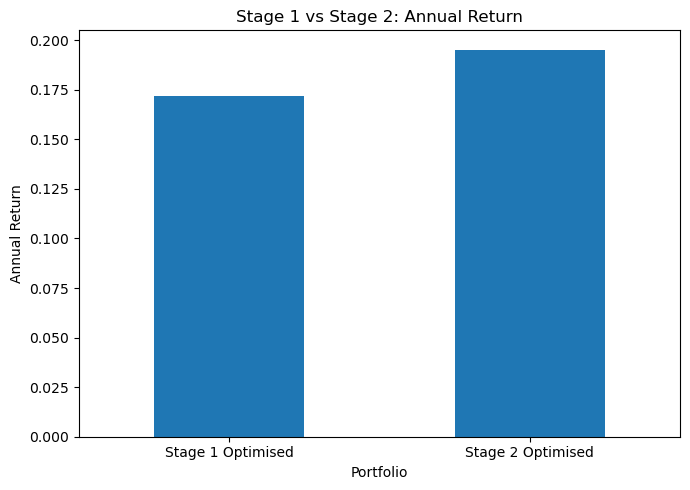

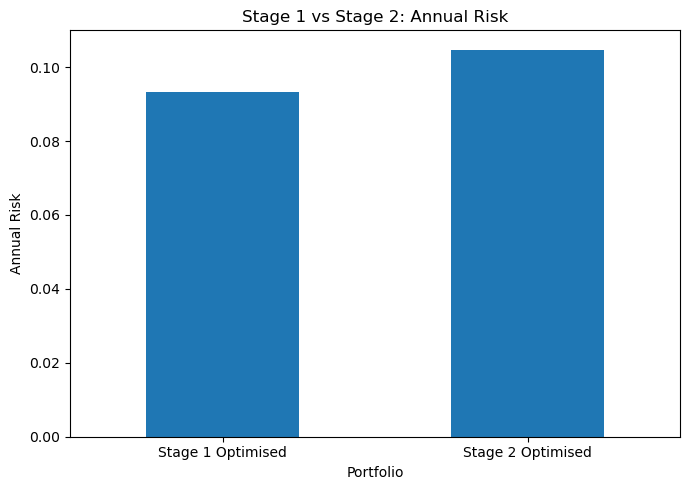

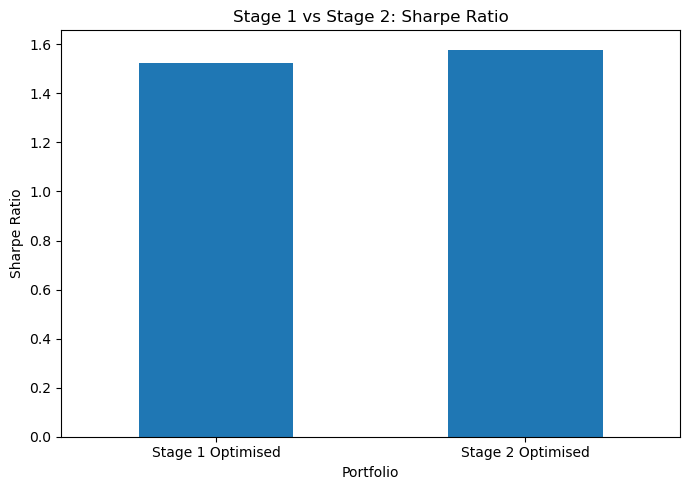

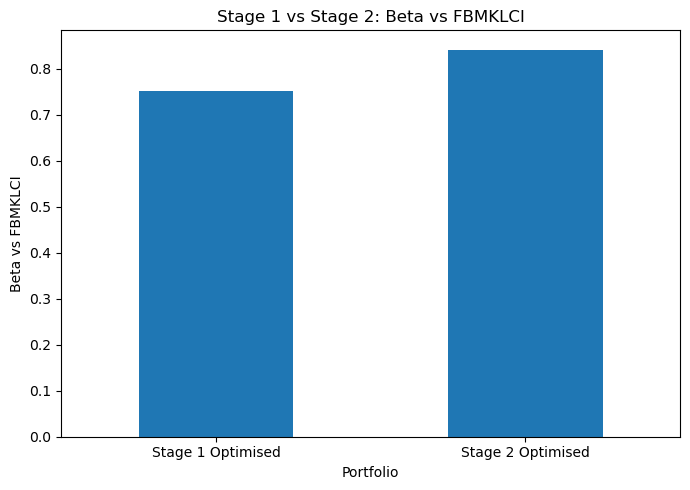

In [118]:
metrics_to_plot = ["Annual Return", "Annual Risk", "Sharpe Ratio", "Beta vs FBMKLCI"]

for metric in metrics_to_plot:
    plt.figure(figsize=(7, 5))
    portfolio_comparison[metric].plot(kind="bar")
    plt.title(f"Stage 1 vs Stage 2: {metric}")
    plt.ylabel(metric)
    plt.xlabel("Portfolio")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f"output/figures/{metric.replace(' ', '_').replace('/', '_')}_comparison.png", dpi=300)
    plt.show()

### Portfolio Metric Interpretation NOOOO

Stage 2 achieved a higher annual return and slightly higher Sharpe ratio than Stage 1, suggesting improved risk-adjusted performance. However, Stage 2 also increased annual risk and beta, meaning the portfolio became more volatile and more sensitive to FBMKLCI movements.

This indicates a trade-off: Stage 2 improves return efficiency but reduces defensive stability compared with Stage 1.

## 3. Optimised Weight Distribution

The weight distribution shows how the optimiser allocated capital across selected stocks.

This helps explain whether the high-volatility additions were actually used by the optimiser or rejected due to poor risk-return characteristics.

<Figure size 1200x600 with 0 Axes>

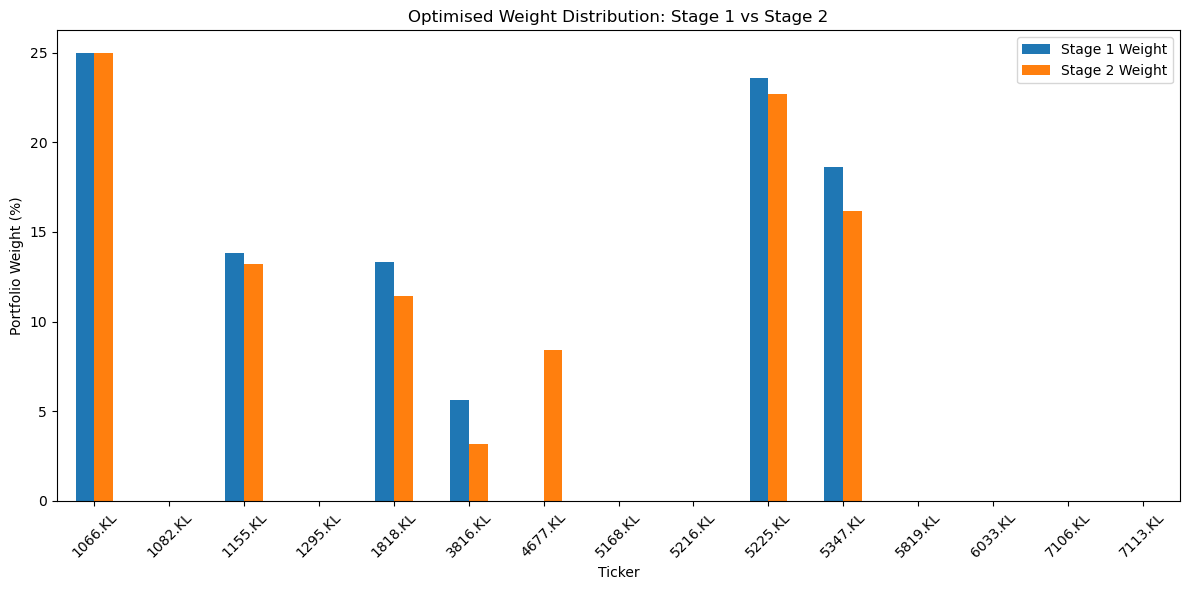

In [119]:
weight_percent = weight_comparison * 100

plt.figure(figsize=(12, 6))
weight_percent.plot(kind="bar", figsize=(12, 6))
plt.title("Optimised Weight Distribution: Stage 1 vs Stage 2")
plt.ylabel("Portfolio Weight (%)")
plt.xlabel("Ticker")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("output/figures/weight_distribution_comparison.png", dpi=300)
plt.show()

### Weight Distribution Interpretation NOOOOO

The optimiser assigned the maximum 25% weight to 1066.KL in both Stage 1 and Stage 2, indicating that it was one of the strongest contributors under the income objective. The 25% cap prevented excessive concentration in this single asset.

In Stage 2, only 4677.KL received a positive allocation among the five high-volatility additions. The other high-volatility stocks received 0% weights, suggesting that their high risk, weak returns, or covariance profile did not improve the optimised income portfolio.

This shows that expanding the universe does not mean all high-volatility stocks are useful. The optimiser selectively included only the asset that improved the portfolio’s return-risk trade-off.

## 4. Individual Stock Risk-Return Scatter Plot

This plot compares selected stocks based on annual risk and annual return.

Stage 1 stocks should generally appear in the lower-risk region, while Stage 2 additions should appear in higher-risk areas.

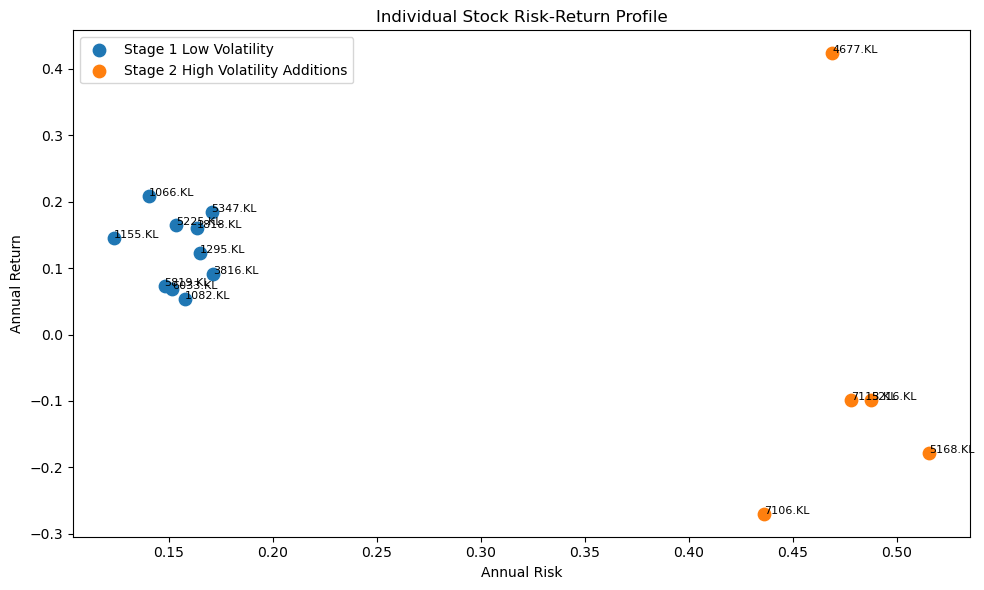

In [120]:
plt.figure(figsize=(10, 6))

stage1_data = individual_metrics[individual_metrics["Stage"] == "Stage 1 Low Volatility"]
stage2_data = individual_metrics[individual_metrics["Stage"] == "Stage 2 High Volatility Addition"]

plt.scatter(
    stage1_data["Annual Risk"],
    stage1_data["Annual Return"],
    label="Stage 1 Low Volatility",
    s=80
)

plt.scatter(
    stage2_data["Annual Risk"],
    stage2_data["Annual Return"],
    label="Stage 2 High Volatility Additions",
    s=80
)

for ticker, row in individual_metrics.iterrows():
    plt.text(row["Annual Risk"], row["Annual Return"], ticker, fontsize=8)

plt.title("Individual Stock Risk-Return Profile")
plt.xlabel("Annual Risk")
plt.ylabel("Annual Return")
plt.legend()
plt.tight_layout()
plt.savefig("output/figures/risk_return_scatter.png", dpi=300)
plt.show()

### Risk-Return Scatter Interpretation NOOOO

The Stage 1 stocks are generally positioned in the lower-risk area, supporting their classification as defensive income-oriented assets. The Stage 2 additions are positioned in the higher-risk region, confirming that they introduce a different volatility regime.

Several Stage 2 additions show negative annual returns despite high annual risk, which explains why the optimiser assigned them 0% weight. However, 4677.KL has both high return and high risk, allowing it to receive a positive allocation in the Stage 2 optimised portfolio.

## 5. Sharpe Ratio Comparison

Sharpe ratio measures risk-adjusted return. A higher Sharpe ratio indicates better return earned per unit of risk.

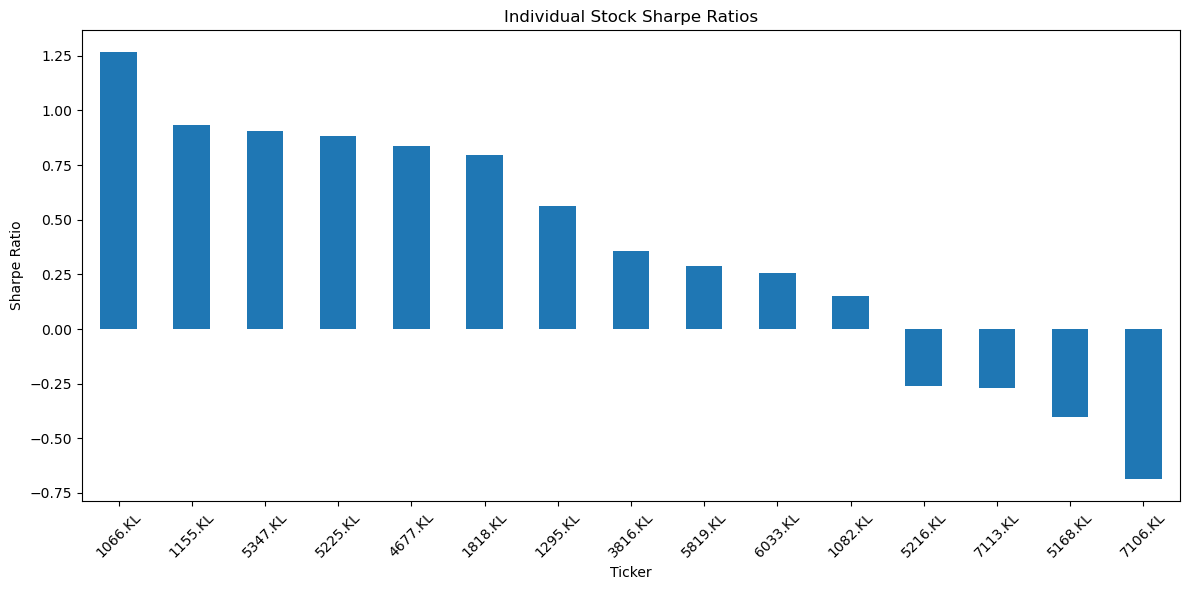

In [121]:
sharpe_sorted = individual_metrics["Sharpe Ratio"].sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sharpe_sorted.plot(kind="bar")
plt.title("Individual Stock Sharpe Ratios")
plt.ylabel("Sharpe Ratio")
plt.xlabel("Ticker")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("output/figures/individual_sharpe_ratios.png", dpi=300)
plt.show()

### Sharpe Ratio Interpretation NOOOOO

Most Stage 1 stocks show positive Sharpe ratios, meaning they delivered returns above the assumed risk-free rate on a risk-adjusted basis. This supports their use in an income-oriented portfolio.

Most Stage 2 high-volatility additions show negative Sharpe ratios, meaning they did not compensate investors for their risk during the sample period. 4677.KL is the exception, with positive risk-adjusted performance, which explains why it received a positive allocation in the Stage 2 optimised portfolio.

## 6. Correlation Heatmap

Correlation helps explain diversification. Higher correlation means stocks move more similarly, reducing diversification benefits.

The Stage 2 heatmap is especially useful because it shows whether high-volatility additions diversify the portfolio or simply add clustered risk.

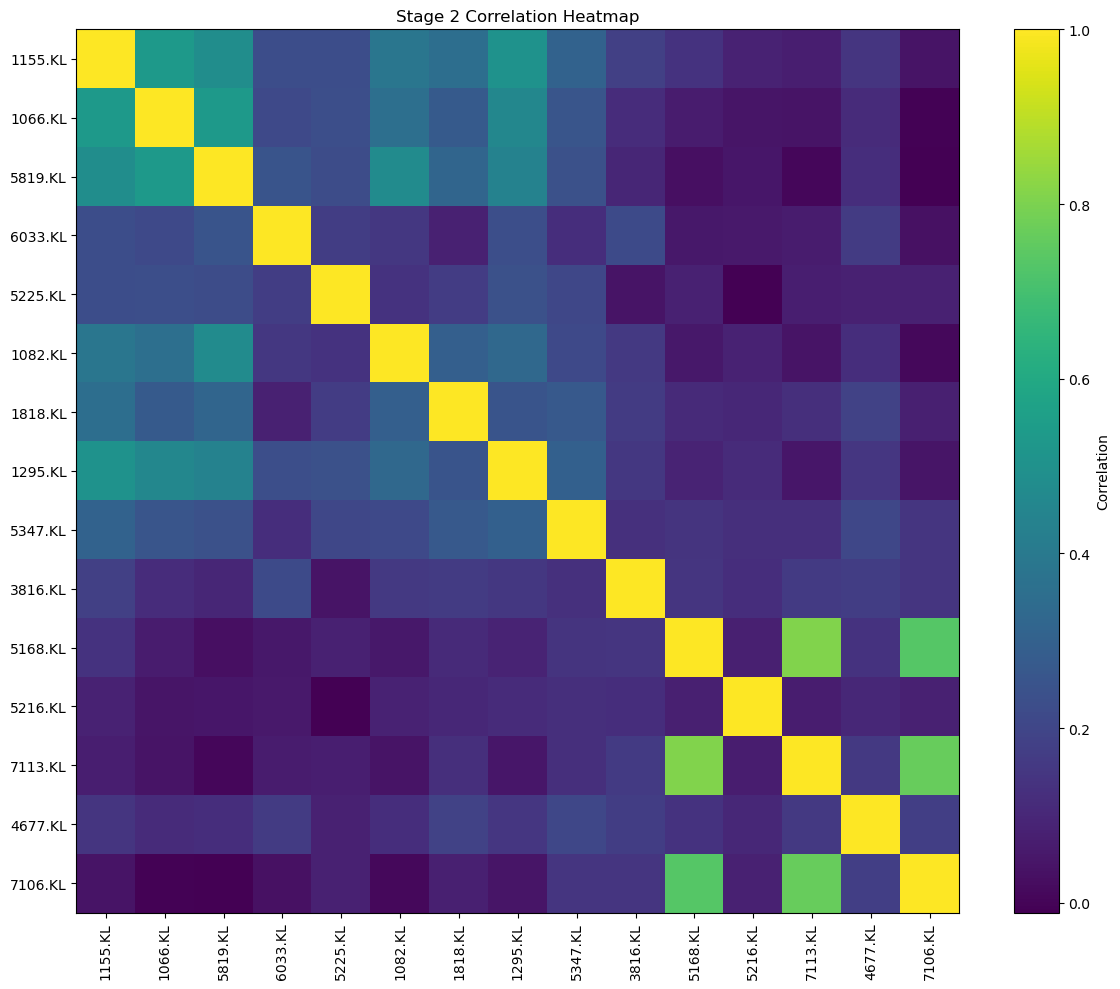

In [122]:
correlation_stage2 = pd.read_csv("output/correlation_stage2.csv", index_col=0)

plt.figure(figsize=(12, 10))
plt.imshow(correlation_stage2, aspect="auto")
plt.colorbar(label="Correlation")
plt.xticks(range(len(correlation_stage2.columns)), correlation_stage2.columns, rotation=90)
plt.yticks(range(len(correlation_stage2.index)), correlation_stage2.index)
plt.title("Stage 2 Correlation Heatmap")
plt.tight_layout()
plt.savefig("output/figures/stage2_correlation_heatmap.png", dpi=300)
plt.show()

### Correlation Interpretation NOOOOOO

The correlation matrix shows moderate correlation among several Stage 1 financial stocks, reflecting sector concentration in the defensive universe.

Among Stage 2 additions, glove-related stocks such as 5168.KL, 7113.KL, and 7106.KL show high correlations with one another. This means that although they are high-volatility assets, they may not provide strong diversification benefits when included together.

This helps explain why the optimiser rejected most high-volatility additions and only allocated weight to 4677.KL.